## **PCA (Principal Component Analysis)**

Considere um conjunto de dados:

$$
X = \{\mathbf{x}_i\}_{i=1}^{N}
$$

onde $\mathbf{x}_i \in \mathbb{R}^{D}$.

Encontrar uma projeção linear dos dados em um subespaço de dimensão $M < D$ tal que a variância das projeções seja maximizada.

Inicialmente, considere a projeção dos dados em um subespaço unidimensional ($M = 1$). Posteriormente, o resultado será generalizado.

Seja $\omega_1 \in \mathbb{R}^{D}$ um vetor unitário que define a direção de projeção. A projeção de cada vetor $\mathbf{x}_i$ nessa direção resulta em um escalar:

$$
z_i = \omega_1^{\top}\mathbf{x}_i
$$


A média das projeções é dada por $\omega_1^{\top}\bar{\mathbf{x}}$, onde $\bar{\mathbf{x}}$ representa a média empírica do conjunto de dados, definida por:

$$
\bar{\mathbf{x}} = \frac{1}{N} \sum_{i=1}^{N} \mathbf{x}_i
$$


Antes de aplicar o PCA, é necessário centralizar o conjunto de dados. A centralização é realizada pela transformação:

$$
\mathbf{x}_n \leftarrow \mathbf{x}_n - \bar{\mathbf{x}}, \quad n = 1, \dots, N
$$

A variância das projeções é dada por:

$$
\frac{1}{N}\sum_{i=1}^{N}(\omega_1^{\top}\mathbf{x}_i - \omega_1^{\top}\bar{\mathbf{x}})^2
$$

Essa expressão pode ser escrita de forma matricial como:

$$
\omega_1^{\top} S \omega_1
$$

onde $S \in \mathbb{R}^{D \times D}$ é a matriz de covariância do conjunto de dados, definida por:

$$
S = \frac{1}{N}\sum_{i=1}^{N}(\mathbf{x}_i - \bar{\mathbf{x}})(\mathbf{x}_i - \bar{\mathbf{x}})^{\top}
$$

A matriz $S$ também pode ser expressa na forma matricial como:

$$
S = \frac{1}{N} X^{\top} X
$$

Desejamos maximizar $\omega_1^{\top} S \omega_1$ com respeito a $\omega_1$, sujeito à restrição $\omega_1^{\top}\omega_1 = 1$.

Para isso, introduzimos um multiplicador de Lagrange $\lambda_1$ e definimos a seguinte função Lagrangiana:

$$
\mathcal{L}(\omega_1, \lambda_1) = \omega_1^{\top} S \omega_1 - \lambda_1(\omega_1^{\top}\omega_1 - 1)
$$

Impondo a condição de otimalidade $\dfrac{\partial \mathcal{L}}{\partial \omega_1} = 0$, obtemos:

$$
S \omega_1 = \lambda_1 \omega_1
$$

Portanto, $\omega_1$ é um autovetor da matriz $S$. Multiplicando ambos os lados da equação por $\omega_1^{\top}$, segue que:

$$
\omega_1^{\top} S \omega_1 = \lambda_1 \omega_1^{\top}\omega_1
$$

Como $\omega_1^{\top}\omega_1 = 1$, temos:

$$
\lambda_1 = \omega_1^{\top} S \omega_1
$$

Assim, o vetor $\omega_1$ ótimo corresponde ao autovetor associado ao maior autovalor de $S$, denotado por $\lambda_1$

Para um subespaço $M$-dimensional, buscamos determinar os $M$ maiores **autovalores** de $S$ e os **autovetores** correspondentes.

A projeção de um vetor de dados $\mathbf{x}_n$ nesse subespaço é dada por:

$$
z_n = W^{\top}\mathbf{x}_n
$$

onde $W \in \mathbb{R}^{D \times M}$ é a matriz formada pelos $M$ autovetores associados aos maiores autovalores de $S$:

$$
W = [\omega_1, \omega_2, \dots, \omega_M]
$$

## Exemplo Prático

Queremos, dado um conjunto $D$ dimensional, reduzir a dimensionalidade para $M = 1$ e $M = 2$.

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("data.csv")

X = df.values

N, D = X.shape
print("Número de amostras:", N)
print("Dimensão dos dados:", D)

Número de amostras: 300
Dimensão dos dados: 3


### Vizualização dos dados

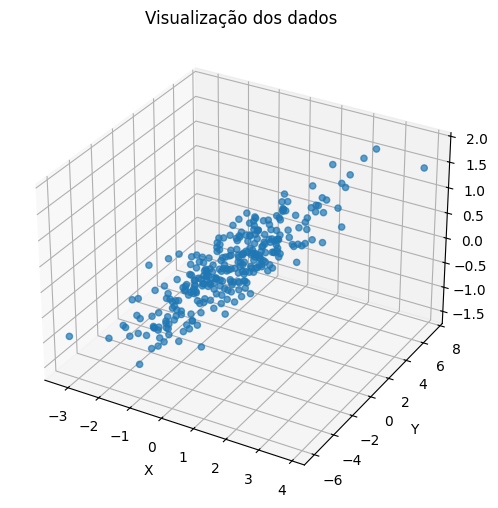

In [2]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(projection="3d")

ax.scatter(X[:,0], X[:,1], X[:,2], alpha=0.7)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.title(r"Visualização dos dados")
plt.show()

### Centralização da Média

In [3]:
mu = np.mean(X, axis=0)

print("Média antes da centralização:", mu)

X_centered = X - mu

print("Média após centralização:", np.mean(X_centered, axis=0))

Média antes da centralização: [-0.00554856 -0.02184211  0.01651146]
Média após centralização: [5.92118946e-18 1.18423789e-17 5.92118946e-18]


### Matriz de Convariância

In [4]:
S = (1/N) * X_centered.T @ X_centered

print("Matriz de covariância S:")
print(S)

Matriz de covariância S:
[[0.96540843 1.91171352 0.46205937]
 [1.91171352 4.01562699 1.0252849 ]
 [0.46205937 1.0252849  0.36292819]]


### Cálculo dos Autovalores e Autovetores

In [5]:
eigenvalues, eigenvectors = np.linalg.eigh(S)

print("Autovalores:")
print(eigenvalues)

print("\nAutovetores:")
print(eigenvectors)


Autovalores:
[0.03366124 0.11281812 5.19748425]

Autovetores:
[[-0.7974259  -0.43189566 -0.42140014]
 [ 0.47774755 -0.02529056 -0.87813305]
 [-0.36860441  0.90156892 -0.22650445]]


In [6]:
idx = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print("Autovalores ordenados:")
print(eigenvalues)

Autovalores ordenados:
[5.19748425 0.11281812 0.03366124]


### PCA para $M = 2$

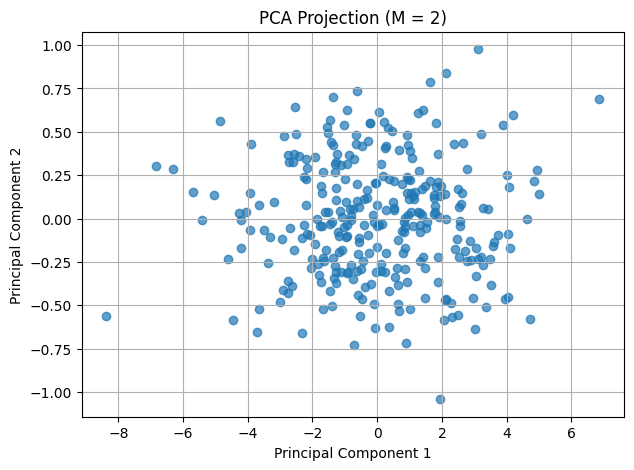

In [7]:
import matplotlib.pyplot as plt

M = 2
W2 = eigenvectors[:, :2]

Z2 = X_centered @ W2

plt.figure(figsize=(7,5))

plt.scatter(Z2[:,0], Z2[:,1], alpha=0.7)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("PCA Projection (M = 2)")

plt.grid(True)
plt.show()

### PCA para $M = 1$

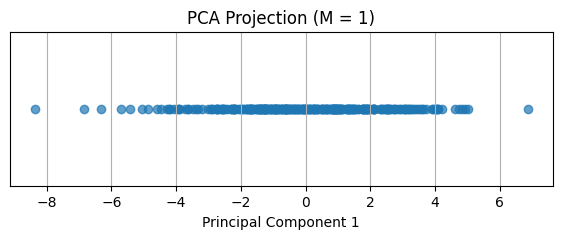

In [8]:
M = 1
W1 = eigenvectors[:, :M]

Z1 = X_centered @ W1

plt.figure(figsize=(7,2))

plt.scatter(Z1[:,0], np.zeros_like(Z1[:,0]), alpha=0.7)

plt.yticks([])

plt.xlabel("Principal Component 1")

plt.title("PCA Projection (M = 1)")

plt.grid(True)
plt.show()